Lets rotate left and flip horizonatally the data to get the correct orientation.

1. Standard hybrid approach:
Processing image: 500x800x3
Analyzing rows 300 to 500 for noise...
Detected 0 noise rows out of 500 total rows
Identifying signal regions to preserve...
Identified 0 rows with significant signal to preserve
Applying hybrid cleaning...
Processed 0 noise rows, preserved 0 signal rows


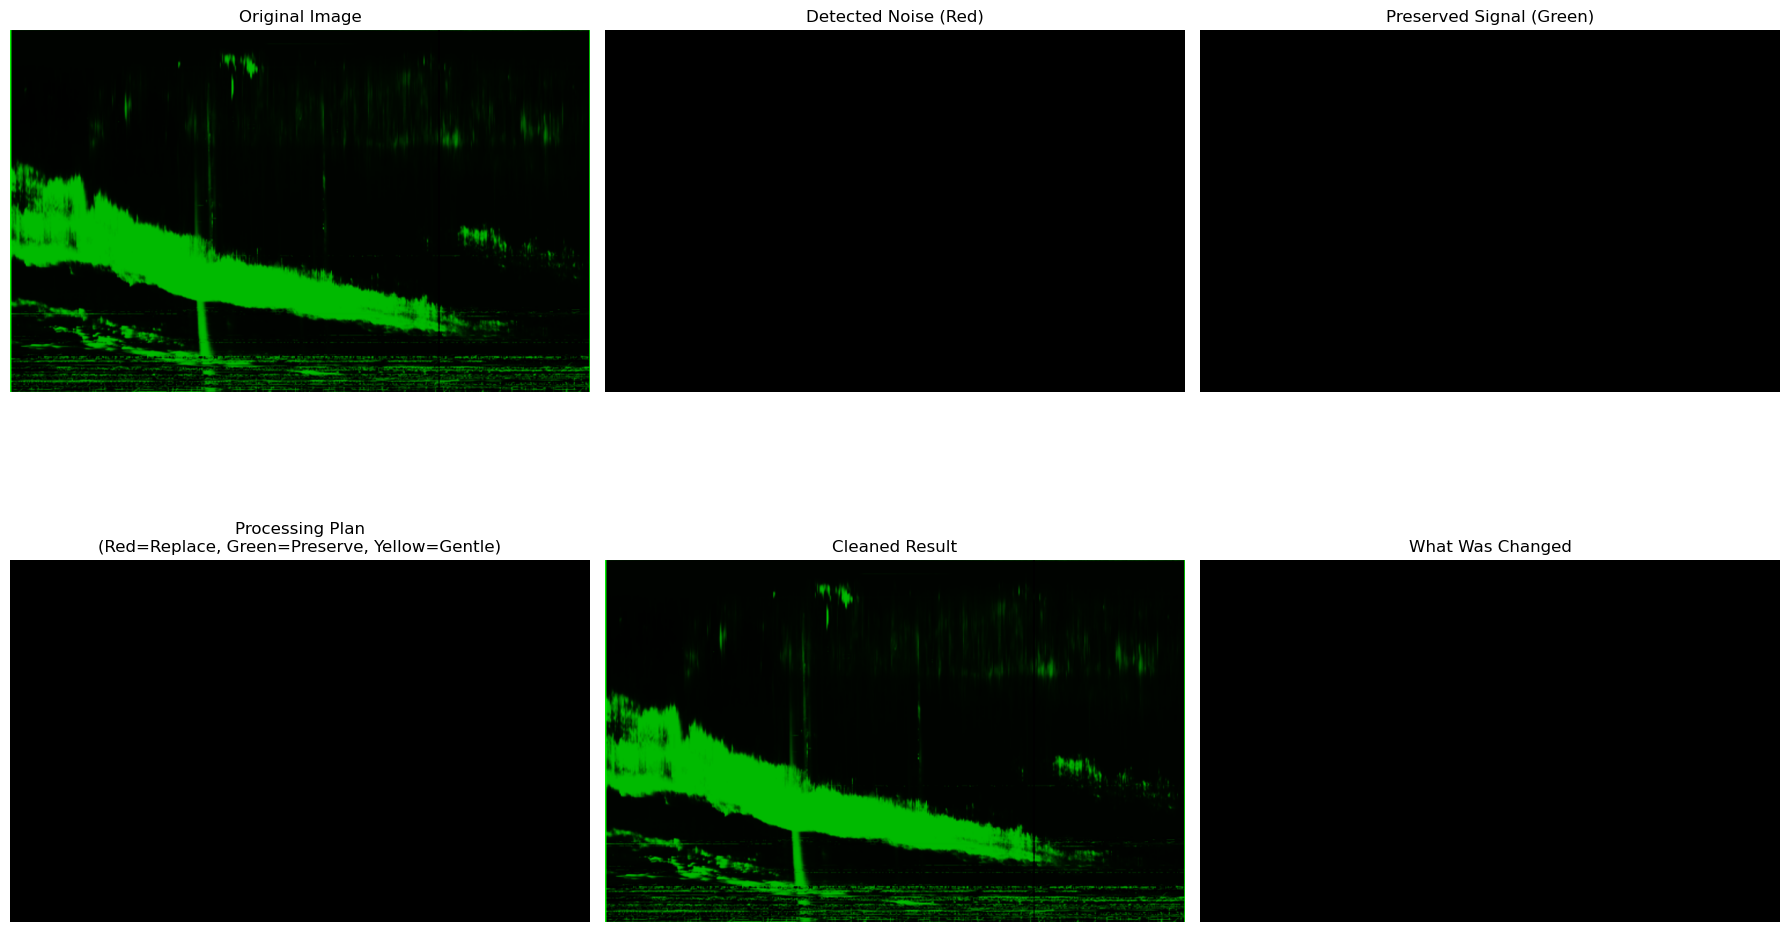

Hybrid cleaned image saved to: hybrid_standard.png

2. More aggressive (preserve less, remove more):
Processing image: 500x800x3
Analyzing rows 300 to 500 for noise...
Detected 0 noise rows out of 500 total rows
Identifying signal regions to preserve...
Identified 139 rows with significant signal to preserve
Applying hybrid cleaning...
Processed 0 noise rows, preserved 106 signal rows


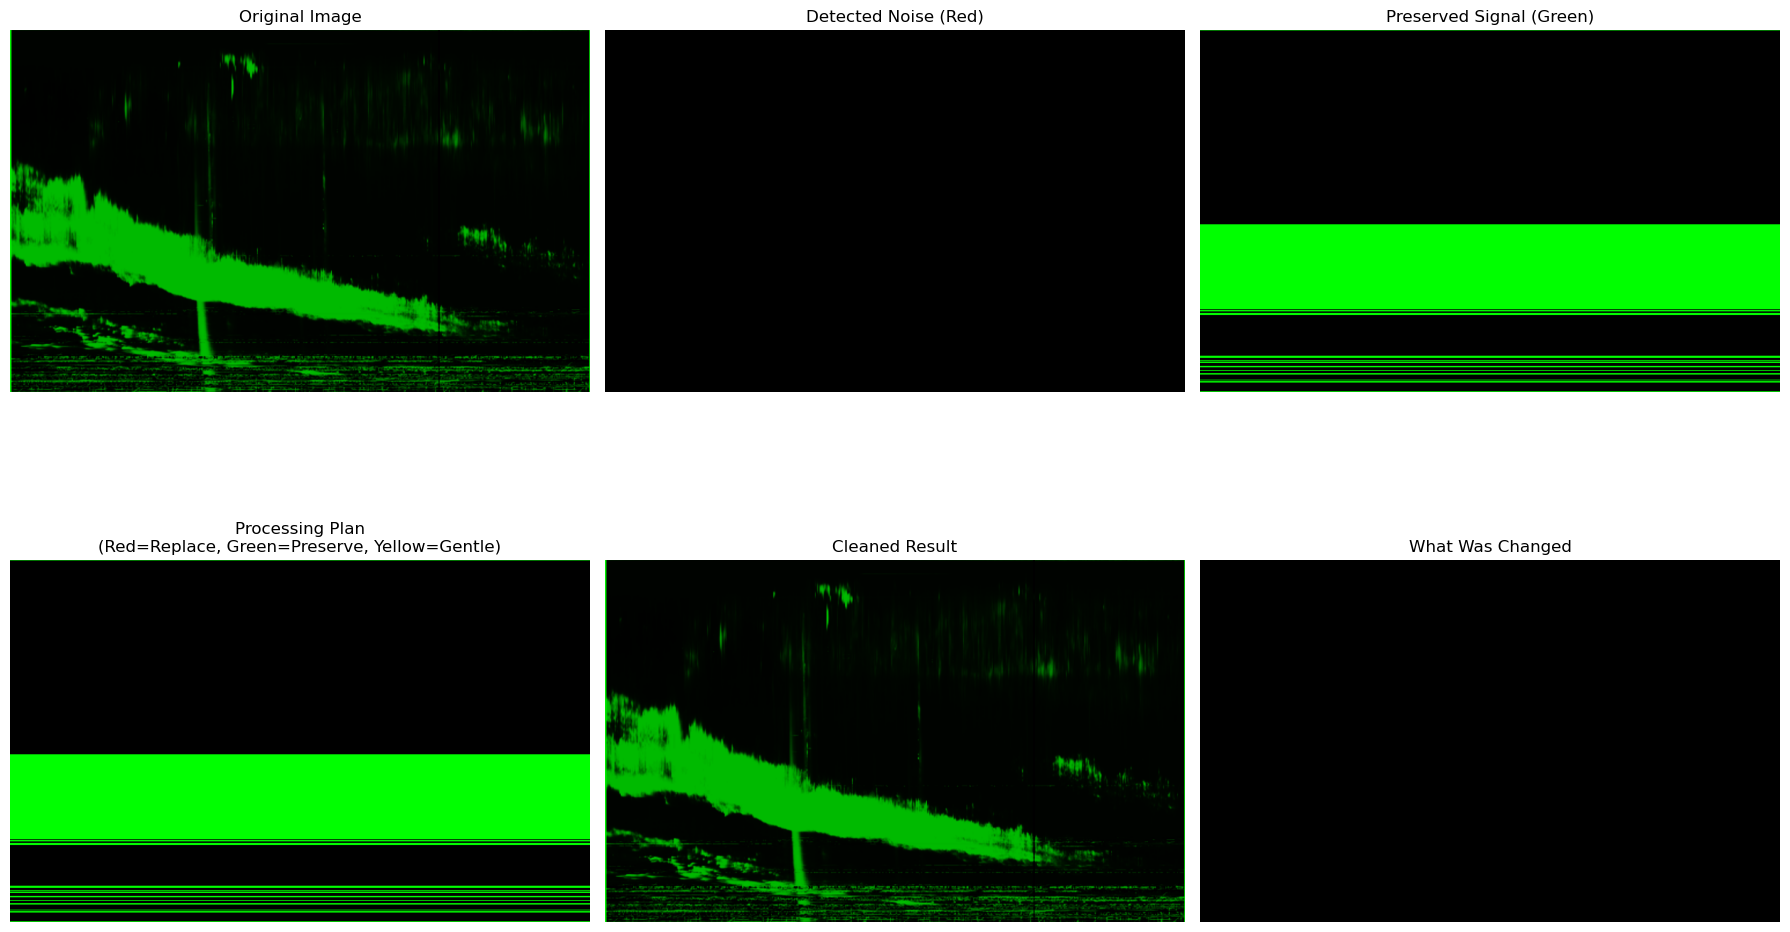

Hybrid cleaned image saved to: hybrid_aggressive.png

3. More conservative (preserve more, remove less):
Processing image: 500x800x3
Analyzing rows 300 to 500 for noise...
Detected 0 noise rows out of 500 total rows
Identifying signal regions to preserve...
Identified 0 rows with significant signal to preserve
Applying hybrid cleaning...
Processed 0 noise rows, preserved 0 signal rows


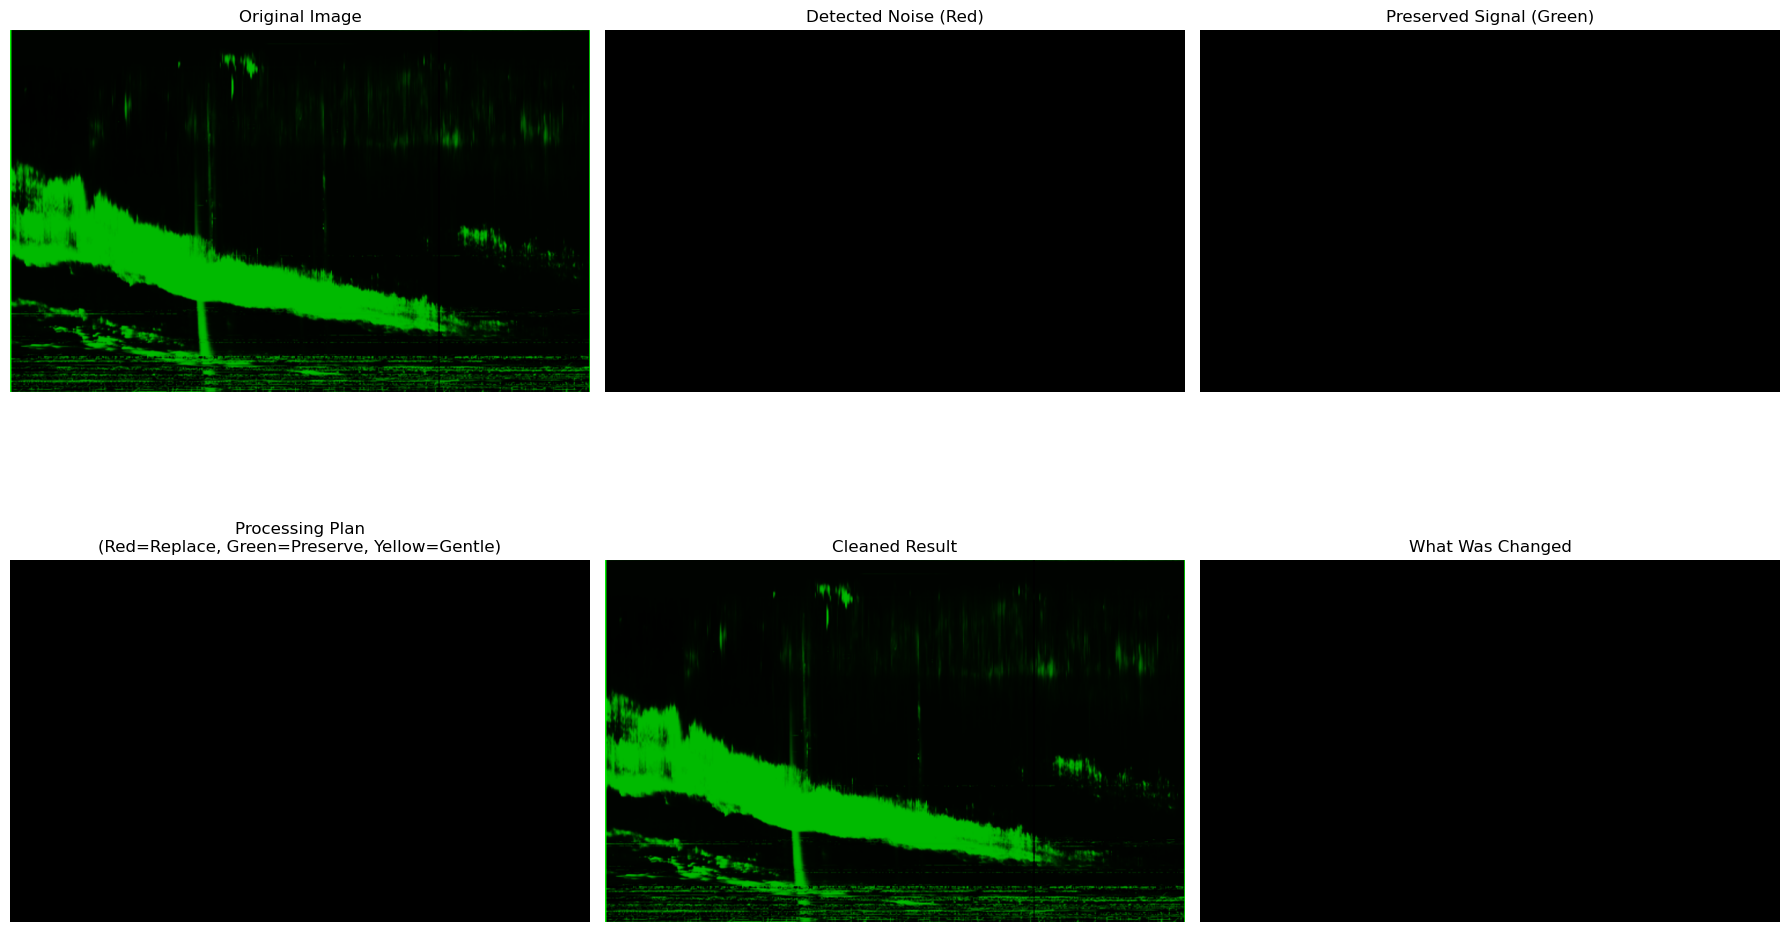

Hybrid cleaned image saved to: hybrid_conservative.png

4. Adaptive (automatically find best parameters):
=== ADAPTIVE HYBRID REMOVAL ===
Trying sensitivity=0.2, preservation=0.7
Processing image: 500x800x3
Analyzing rows 300 to 500 for noise...
Detected 0 noise rows out of 500 total rows
Identifying signal regions to preserve...
Identified 4 rows with significant signal to preserve
Applying hybrid cleaning...
Processed 0 noise rows, preserved 3 signal rows
  Score: 8 (noise_removed: 0, signal_preserved: 4)
Trying sensitivity=0.2, preservation=0.8
Processing image: 500x800x3
Analyzing rows 300 to 500 for noise...
Detected 0 noise rows out of 500 total rows
Identifying signal regions to preserve...
Identified 0 rows with significant signal to preserve
Applying hybrid cleaning...
Processed 0 noise rows, preserved 0 signal rows
  Score: 0 (noise_removed: 0, signal_preserved: 0)
Trying sensitivity=0.2, preservation=0.9
Processing image: 500x800x3
Analyzing rows 300 to 500 for noise...
Dete

In [28]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage

def hybrid_noise_removal(image_path, output_path=None, 
                        signal_preservation_threshold=0.8,
                        noise_detection_sensitivity=0.3,
                        lower_region_start=0.6,
                        show_analysis=True):
    """
    Hybrid approach: Use sliding window to detect noise regions,
    then apply extreme removal only to confirmed noise areas.
    Preserves signal areas that were incorrectly targeted by extreme removal.
    
    Parameters:
    - signal_preservation_threshold: Higher = preserve more potential signal (0.5-1.0)
    - noise_detection_sensitivity: Lower = more aggressive noise detection (0.1-0.5)
    - lower_region_start: Where to start looking for noise (0.5-0.8)
    """
    
    img = cv2.imread(image_path)
    if img is None:
        raise ValueError("Could not load image")
    
    h, w, c = img.shape
    print(f"Processing image: {h}x{w}x{c}")
    
    # Step 1: Use sliding window to create a "noise map"
    noise_map = create_noise_map(img, noise_detection_sensitivity, lower_region_start)
    
    # Step 2: Identify signal regions that should be preserved
    signal_map = identify_signal_regions(img, noise_map, signal_preservation_threshold)
    
    # Step 3: Apply hybrid cleaning
    result = apply_hybrid_cleaning(img, noise_map, signal_map, lower_region_start)
    
    if show_analysis:
        show_hybrid_analysis(img, noise_map, signal_map, result)
    
    if output_path:
        cv2.imwrite(output_path, result)
        print(f"Hybrid cleaned image saved to: {output_path}")
    
    return result, noise_map, signal_map

def create_noise_map(img, sensitivity, lower_region_start):
    """
    Create a binary map indicating which rows are likely noise.
    Uses sliding window analysis across full x-axis.
    """
    
    h, w, c = img.shape
    noise_map = np.zeros(h, dtype=bool)
    
    # Focus on lower region where noise typically occurs
    analysis_start = int(h * lower_region_start)
    
    print(f"Analyzing rows {analysis_start} to {h} for noise...")
    
    # Analyze each channel and combine results
    channel_noise_maps = []
    
    for channel in range(c):
        channel_data = img[:, :, channel]
        channel_noise = np.zeros(h, dtype=bool)
        
        # Calculate statistics for the region we're analyzing
        analysis_region = channel_data[analysis_start:, :]
        
        if analysis_region.shape[0] > 0:
            # Row-wise statistics
            row_variances = np.var(analysis_region, axis=1)
            row_means = np.mean(analysis_region, axis=1)
            row_ranges = np.max(analysis_region, axis=1) - np.min(analysis_region, axis=1)
            
            # Calculate thresholds
            var_threshold = np.mean(row_variances) * sensitivity
            range_threshold = np.mean(row_ranges) * sensitivity
            
            # Identify noise rows
            low_variance_rows = row_variances < var_threshold
            low_range_rows = row_ranges < range_threshold
            
            # Combine criteria (both low variance AND low range = likely noise)
            noise_rows_in_region = low_variance_rows & low_range_rows
            
            # Map back to full image coordinates
            noise_indices = analysis_start + np.where(noise_rows_in_region)[0]
            channel_noise[noise_indices] = True
            
        channel_noise_maps.append(channel_noise)
    
    # Combine channel results (row is noise if it's noise in majority of channels)
    for row in range(h):
        noise_count = sum([channel_map[row] for channel_map in channel_noise_maps])
        noise_map[row] = noise_count >= (c // 2 + 1)  # Majority vote
    
    detected_noise = np.sum(noise_map)
    print(f"Detected {detected_noise} noise rows out of {h} total rows")
    
    return noise_map

def identify_signal_regions(img, noise_map, preservation_threshold):
    """
    Identify regions that contain signal and should be preserved.
    """
    
    h, w, c = img.shape
    signal_map = np.zeros(h, dtype=bool)
    
    print("Identifying signal regions to preserve...")
    
    # Calculate signal strength for each row
    for channel in range(c):
        channel_data = img[:, :, channel]
        
        # Signal indicators: high variance, high range, interesting patterns
        row_variances = np.var(channel_data, axis=1)
        row_ranges = np.max(channel_data, axis=1) - np.min(channel_data, axis=1)
        row_gradients = np.abs(np.gradient(np.mean(channel_data, axis=1)))
        
        # Normalize to 0-1 scale
        var_norm = row_variances / (np.max(row_variances) + 1e-8)
        range_norm = row_ranges / (np.max(row_ranges) + 1e-8)
        grad_norm = row_gradients / (np.max(row_gradients) + 1e-8)
        
        # Combined signal strength
        signal_strength = (var_norm + range_norm + grad_norm) / 3
        
        # Rows with high signal strength should be preserved
        strong_signal = signal_strength > preservation_threshold
        signal_map = signal_map | strong_signal
    
    # Don't preserve rows that are definitively noise
    signal_map = signal_map & ~noise_map
    
    signal_count = np.sum(signal_map)
    print(f"Identified {signal_count} rows with significant signal to preserve")
    
    return signal_map

def apply_hybrid_cleaning(img, noise_map, signal_map, lower_region_start):
    """
    Apply cleaning using the combined information from noise and signal maps.
    """
    
    h, w, c = img.shape
    result = img.copy()
    
    split_point = int(h * lower_region_start)
    clean_region = img[:split_point, :]
    
    print("Applying hybrid cleaning...")
    
    # Get reference data for replacement
    avg_color = np.mean(clean_region, axis=(0, 1))
    last_clean_row = clean_region[-1:, :]
    
    # Process each row individually
    for row in range(split_point, h):
        if noise_map[row] and not signal_map[row]:
            # This row is noise and doesn't contain significant signal - replace it
            
            # Method 1: Try interpolation from nearby clean rows first
            replacement_row = get_interpolated_replacement(img, row, signal_map, noise_map)
            
            if replacement_row is not None:
                result[row, :, :] = replacement_row
            else:
                # Method 2: Use extended clean row with variation
                extended_row = np.tile(last_clean_row, (1, 1, 1))
                noise = np.random.randint(-5, 6, extended_row.shape, dtype=np.int16)
                extended_row = np.clip(extended_row.astype(np.int16) + noise, 0, 255).astype(np.uint8)
                result[row, :, :] = extended_row[0]
        
        elif noise_map[row] and signal_map[row]:
            # This row has both noise and signal - apply gentle cleaning
            result[row, :, :] = apply_gentle_cleaning(img[row, :, :])
    
    processed_rows = np.sum(noise_map[split_point:])
    preserved_rows = np.sum(signal_map[split_point:])
    
    print(f"Processed {processed_rows} noise rows, preserved {preserved_rows} signal rows")
    
    return result

def get_interpolated_replacement(img, target_row, signal_map, noise_map):
    """
    Find nearby clean rows and interpolate to create replacement.
    """
    
    h = img.shape[0]
    
    # Look for clean rows above and below
    above_row = None
    below_row = None
    
    # Search upward
    for r in range(target_row - 1, -1, -1):
        if not noise_map[r]:  # Clean row
            above_row = r
            break
        if target_row - r > 10:  # Don't search too far
            break
    
    # Search downward  
    for r in range(target_row + 1, h):
        if not noise_map[r]:  # Clean row
            below_row = r
            break
        if r - target_row > 10:  # Don't search too far
            break
    
    # Interpolate if we found clean rows
    if above_row is not None and below_row is not None:
        distance_above = target_row - above_row
        distance_below = below_row - target_row
        total_distance = distance_above + distance_below
        
        # Weighted interpolation based on distance
        weight_above = distance_below / total_distance
        weight_below = distance_above / total_distance
        
        interpolated = (weight_above * img[above_row, :, :] + 
                       weight_below * img[below_row, :, :])
        return interpolated.astype(np.uint8)
    
    elif above_row is not None:
        return img[above_row, :, :]
    elif below_row is not None:
        return img[below_row, :, :]
    
    return None

def apply_gentle_cleaning(row_data):
    """
    Apply gentle cleaning to rows that have both signal and noise.
    """
    
    # Use median filter to reduce noise while preserving signal
    cleaned = ndimage.median_filter(row_data, size=(1, 3))
    
    # Blend with original to preserve signal characteristics
    result = 0.7 * cleaned + 0.3 * row_data
    
    return result.astype(np.uint8)

def show_hybrid_analysis(original, noise_map, signal_map, result):
    """
    Show detailed analysis of the hybrid approach.
    """
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    
    # Convert BGR to RGB for display
    orig_rgb = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)
    result_rgb = cv2.cvtColor(result, cv2.COLOR_BGR2RGB)
    
    # Original image
    axes[0, 0].imshow(orig_rgb)
    axes[0, 0].set_title('Original Image')
    axes[0, 0].axis('off')
    
    # Noise map visualization
    h, w = noise_map.shape[0], orig_rgb.shape[1]
    noise_viz = np.zeros((h, w, 3), dtype=np.uint8)
    noise_viz[noise_map, :, :] = [255, 0, 0]  # Red for noise
    axes[0, 1].imshow(noise_viz)
    axes[0, 1].set_title('Detected Noise (Red)')
    axes[0, 1].axis('off')
    
    # Signal map visualization
    signal_viz = np.zeros((h, w, 3), dtype=np.uint8)
    signal_viz[signal_map, :, :] = [0, 255, 0]  # Green for signal
    axes[0, 2].imshow(signal_viz)
    axes[0, 2].set_title('Preserved Signal (Green)')
    axes[0, 2].axis('off')
    
    # Combined analysis
    combined_viz = np.zeros((h, w, 3), dtype=np.uint8)
    combined_viz[noise_map & ~signal_map, :, :] = [255, 0, 0]  # Red: will be replaced
    combined_viz[signal_map, :, :] = [0, 255, 0]  # Green: will be preserved
    combined_viz[noise_map & signal_map, :, :] = [255, 255, 0]  # Yellow: gentle cleaning
    axes[1, 0].imshow(combined_viz)
    axes[1, 0].set_title('Processing Plan\n(Red=Replace, Green=Preserve, Yellow=Gentle)')
    axes[1, 0].axis('off')
    
    # Result
    axes[1, 1].imshow(result_rgb)
    axes[1, 1].set_title('Cleaned Result')
    axes[1, 1].axis('off')
    
    # Difference
    diff = cv2.absdiff(original, result)
    diff_rgb = cv2.cvtColor(diff, cv2.COLOR_BGR2RGB)
    axes[1, 2].imshow(diff_rgb)
    axes[1, 2].set_title('What Was Changed')
    axes[1, 2].axis('off')
    
    plt.tight_layout()
    plt.show()

def adaptive_hybrid_removal(image_path, output_path=None):
    """
    Adaptive version that automatically determines the best parameters.
    """
    
    print("=== ADAPTIVE HYBRID REMOVAL ===")
    
    # Try multiple parameter combinations and choose the best
    sensitivity_values = [0.2, 0.3, 0.4]
    preservation_values = [0.7, 0.8, 0.9]
    
    best_result = None
    best_params = None
    best_score = -1
    
    for sens in sensitivity_values:
        for pres in preservation_values:
            print(f"Trying sensitivity={sens}, preservation={pres}")
            
            result, noise_map, signal_map = hybrid_noise_removal(
                image_path, 
                noise_detection_sensitivity=sens,
                signal_preservation_threshold=pres,
                show_analysis=False
            )
            
            # Score this result (balance between noise removal and signal preservation)
            noise_removed = np.sum(noise_map)
            signal_preserved = np.sum(signal_map)
            score = noise_removed + signal_preserved * 2  # Weight signal preservation higher
            
            print(f"  Score: {score} (noise_removed: {noise_removed}, signal_preserved: {signal_preserved})")
            
            if score > best_score:
                best_score = score
                best_result = result
                best_params = (sens, pres)
    
    print(f"Best parameters: sensitivity={best_params[0]}, preservation={best_params[1]}")
    
    if output_path:
        cv2.imwrite(output_path, best_result)
        print(f"Adaptive result saved to: {output_path}")
    
    return best_result

# USAGE
if __name__ == "__main__":
    image_path = "filtered_image_3.png"
    
    print("1. Standard hybrid approach:")
    result1, noise_map, signal_map = hybrid_noise_removal(
        image_path,
        "hybrid_standard.png",
        signal_preservation_threshold=0.8,
        noise_detection_sensitivity=0.3
    )
    
    print("\n2. More aggressive (preserve less, remove more):")
    result2, _, _ = hybrid_noise_removal(
        image_path,
        "hybrid_aggressive.png", 
        signal_preservation_threshold=0.6,
        noise_detection_sensitivity=0.2
    )
    
    print("\n3. More conservative (preserve more, remove less):")
    result3, _, _ = hybrid_noise_removal(
        image_path,
        "hybrid_conservative.png",
        signal_preservation_threshold=0.9, 
        noise_detection_sensitivity=0.4
    )
    
    print("\n4. Adaptive (automatically find best parameters):")
    result4 = adaptive_hybrid_removal(image_path, "hybrid_adaptive.png")

Removed 0 static rows


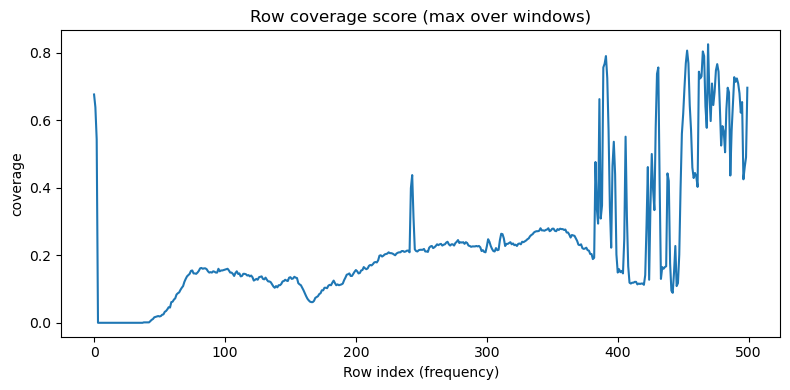

In [ ]:
import cv2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from scipy import ndimage

def aggressive_horizontal_noise_removal(image_path, output_path=None, 
                                      noise_threshold=0.3, 
                                      lower_region_ratio=0.7,
                                      show_progress=True):
    """
    Aggressive removal of horizontal line noise, especially effective for 
    static-like horizontal lines in the lower portion of images.
    """
    
    # Load image
    img = cv2.imread(image_path)
    if img is None:
        raise ValueError("Could not load image")
    
    # Work with each channel separately to preserve color
    channels = cv2.split(img)
    cleaned_channels = []
    
    for channel in channels:
        h, w = channel.shape
        
        # Define the region where noise is present (lower portion)
        noise_start_row = int(h * lower_region_ratio)
        
        # Extract regions
        clean_region = channel[:noise_start_row, :].copy()
        noisy_region = channel[noise_start_row:, :].copy()
        
        if show_progress:
            print(f"Processing region from row {noise_start_row} to {h}")
        
        # METHOD 1: Line-by-line variance analysis
        cleaned_noisy = remove_horizontal_lines_by_variance(noisy_region, noise_threshold)
        
        # METHOD 2: Frequency domain filtering
        cleaned_noisy = frequency_domain_horizontal_filter(cleaned_noisy)
        
        # METHOD 3: Morphological operations with multiple kernel sizes
        cleaned_noisy = multi_scale_morphological_filter(cleaned_noisy)
        
        # Reconstruct the full channel
        cleaned_channel = np.vstack([clean_region, cleaned_noisy])
        cleaned_channels.append(cleaned_channel)
    
    # Merge channels back
    cleaned_img = cv2.merge(cleaned_channels)
    
    if output_path:
        cv2.imwrite(output_path, cleaned_img)
        print(f"Aggressively cleaned image saved to: {output_path}")
    
    if show_progress:
        show_before_after(img, cleaned_img)
    
    return cleaned_img

def remove_horizontal_lines_by_variance(region, threshold=0.3):
    """
    Remove horizontal lines by analyzing row variance and replacing 
    noisy rows with interpolated values.
    """
    h, w = region.shape
    cleaned = region.copy()
    
    # Calculate variance for each row
    row_variances = np.var(region, axis=1)
    mean_variance = np.mean(row_variances)
    
    # Identify rows with unusually low variance (likely noise lines)
    noise_rows = row_variances < (threshold * mean_variance)
    
    print(f"Detected {np.sum(noise_rows)} noisy rows out of {h}")
    
    # Replace noisy rows with interpolated values
    for i in range(h):
        if noise_rows[i]:
            # Find nearest non-noisy rows
            above = i - 1
            below = i + 1
            
            while above >= 0 and noise_rows[above]:
                above -= 1
            while below < h and noise_rows[below]:
                below += 1
            
            # Interpolate
            if above >= 0 and below < h:
                # Linear interpolation between above and below
                alpha = (i - above) / (below - above)
                cleaned[i, :] = (1 - alpha) * region[above, :] + alpha * region[below, :]
            elif above >= 0:
                cleaned[i, :] = region[above, :]
            elif below < h:
                cleaned[i, :] = region[below, :]
    
    return cleaned

def frequency_domain_horizontal_filter(region):
    """
    Remove horizontal patterns using frequency domain filtering.
    """
    # Convert to float
    region_float = region.astype(np.float32)
    
    # Apply FFT
    f_transform = np.fft.fft2(region_float)
    f_shift = np.fft.fftshift(f_transform)
    
    # Create a mask to remove horizontal frequencies
    h, w = region.shape
    center_row = h // 2
    
    # Create horizontal line filter (remove frequencies corresponding to horizontal lines)
    mask = np.ones((h, w), dtype=np.complex128)
    
    # Remove horizontal line frequencies (rows near the center in frequency domain)
    line_thickness = 3  # Adjust this to target different line thicknesses
    mask[center_row-line_thickness:center_row+line_thickness+1, :] *= 0.1
    
    # Apply mask and inverse transform
    f_shift_filtered = f_shift * mask
    f_ishift = np.fft.ifftshift(f_shift_filtered)
    img_back = np.fft.ifft2(f_ishift)
    img_back = np.real(img_back)
    
    return np.clip(img_back, 0, 255).astype(np.uint8)

def multi_scale_morphological_filter(region):
    """
    Apply morphological filtering with multiple kernel sizes to catch 
    different types of horizontal lines.
    """
    cleaned = region.copy()
    
    # Multiple horizontal kernels of different sizes
    kernel_sizes = [(10, 1), (20, 1), (40, 1), (60, 1)]
    
    for ksize in kernel_sizes:
        kernel = cv2.getStructuringElement(cv2.MORPH_RECT, ksize)
        
        # Detect horizontal structures
        horizontal_lines = cv2.morphologyEx(cleaned, cv2.MORPH_OPEN, kernel)
        
        # Subtract them (but be gentle to avoid over-processing)
        difference = cv2.subtract(cleaned, horizontal_lines)
        cleaned = cv2.addWeighted(cleaned, 0.7, difference, 0.3, 0)
    
    return cleaned

def extreme_horizontal_noise_removal(image_path, output_path=None):
    """
    Most aggressive approach - completely replaces the lower noisy region
    with a clean background based on the upper region.
    """
    
    img = cv2.imread(image_path)
    h, w, c = img.shape
    
    # Define split point
    split_point = int(h * 0.75)  # Adjust this based on where noise starts
    
    clean_region = img[:split_point, :]
    noisy_region = img[split_point:, :]
    
    # Method 1: Replace with average color from clean region
    avg_color = np.mean(clean_region, axis=(0, 1))
    replacement_region = np.full_like(noisy_region, avg_color, dtype=np.uint8)
    
    # Method 2: Extend the last clean row downward with some noise
    last_clean_row = clean_region[-1:, :]
    extended_region = np.tile(last_clean_row, (noisy_region.shape[0], 1, 1))
    
    # Add some subtle variation to make it look natural
    noise = np.random.randint(-10, 11, extended_region.shape, dtype=np.int16)
    extended_region = np.clip(extended_region.astype(np.int16) + noise, 0, 255).astype(np.uint8)
    
    # Combine
    result = np.vstack([clean_region, extended_region])
    
    if output_path:
        cv2.imwrite(output_path, result)
        print(f"Extreme cleaning completed: {output_path}")
    
    return result

def median_row_replacement(image_path, output_path=None, lower_region_ratio=0.7):
    """
    Replace each row in the noisy region with the median of surrounding rows.
    """
    
    img = cv2.imread(image_path)
    h, w, c = img.shape
    
    split_point = int(h * lower_region_ratio)
    result = img.copy()
    
    # Process the noisy region
    window_size = 5  # Number of rows to consider for median
    
    for row in range(split_point, h):
        # Get window of rows around current row
        start_row = max(0, row - window_size // 2)
        end_row = min(h, row + window_size // 2 + 1)
        
        # Calculate median for each pixel position
        window = img[start_row:end_row, :, :]
        median_row = np.median(window, axis=0)
        
        result[row, :, :] = median_row.astype(np.uint8)
    
    if output_path:
        cv2.imwrite(output_path, result)
        print(f"Median row replacement completed: {output_path}")
    
    return result

def show_before_after(original, cleaned):
    """
    Display before and after comparison.
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 8))
    
    # Convert BGR to RGB for display
    original_rgb = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)
    cleaned_rgb = cv2.cvtColor(cleaned, cv2.COLOR_BGR2RGB)
    
    ax1.imshow(original_rgb)
    ax1.set_title('Original (with noise)', fontsize=14)
    ax1.axis('off')
    
    ax2.imshow(cleaned_rgb)
    ax2.set_title('Cleaned (noise removed)', fontsize=14)
    ax2.axis('off')
    
    plt.tight_layout()
    plt.show()

# USAGE EXAMPLES:
if __name__ == "__main__":
    image_path = "filtered_image_2.png"
    
    print("=== TRYING AGGRESSIVE REMOVAL ===")
    result1 = aggressive_horizontal_noise_removal(
        image_path, 
        "aggressive_cleaned.png",
        noise_threshold=0.5,  # Lower = more aggressive
        lower_region_ratio=0.6  # Adjust where noise starts
    )
    
    print("\n=== TRYING EXTREME REMOVAL ===")
    result2 = extreme_horizontal_noise_removal(
        image_path,
        "extreme_cleaned.png"
    )
    
    print("\n=== TRYING MEDIAN ROW REPLACEMENT ===")
    result3 = median_row_replacement(
        image_path,
        "median_cleaned.png",
        lower_region_ratio=0.6
    )
    
    print("\nTry all three methods and see which works best for your specific noise pattern!")